In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_preprocessing import load_processed
from src.model_training import train_neural_network
from src.evaluation import evaluate_model
from src.visualization import plot_confusion_matrix, plot_roc_curves, plot_pr_curves

I0000 00:00:1781267537.677078   31205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781267537.712172   31205 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781267538.639617   31205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
X_train, X_test, y_train, y_test = load_processed()

## Train

In [3]:
model = train_neural_network(X_train, y_train)
print('Training complete.')

Epoch 1/20


/home/suman/miniforge3/envs/ml-system/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781267540.821052   31205 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1781267540.930375   31205 cpu_allocator_impl.cc:82] Allocation of 21873120 exceeds 10% of free system memory.


5697/5697 ━━━━━━━━━━━━━━━━━━━━ 5s 799us/step - accuracy: 0.9991 - loss: 0.0070 - val_accuracy: 0.9992 - val_loss: 0.0034
Epoch 2/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 758us/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0034
Epoch 3/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 736us/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.9995 - val_loss: 0.0031
Epoch 4/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 746us/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 5/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 749us/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9994 - val_loss: 0.0030
Epoch 6/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 740us/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9995 - val_loss: 0.0032
Epoch 7/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 748us/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9995 - val_loss: 0.0032
Epoch 8/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 779us/step - accuracy: 0.9996 - loss: 0.00

## Evaluate

In [10]:
y_prob = model.predict(X_test)
y_pred = (y_prob>0.5).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## CONFUSION MATRIX

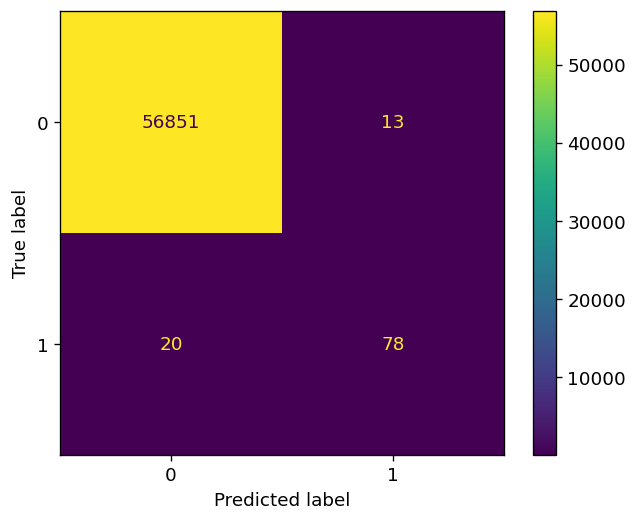

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

## ROC-AUC curve

In [15]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [16]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

In [17]:
auc_score = roc_auc_score(
    y_test,
    y_prob
)

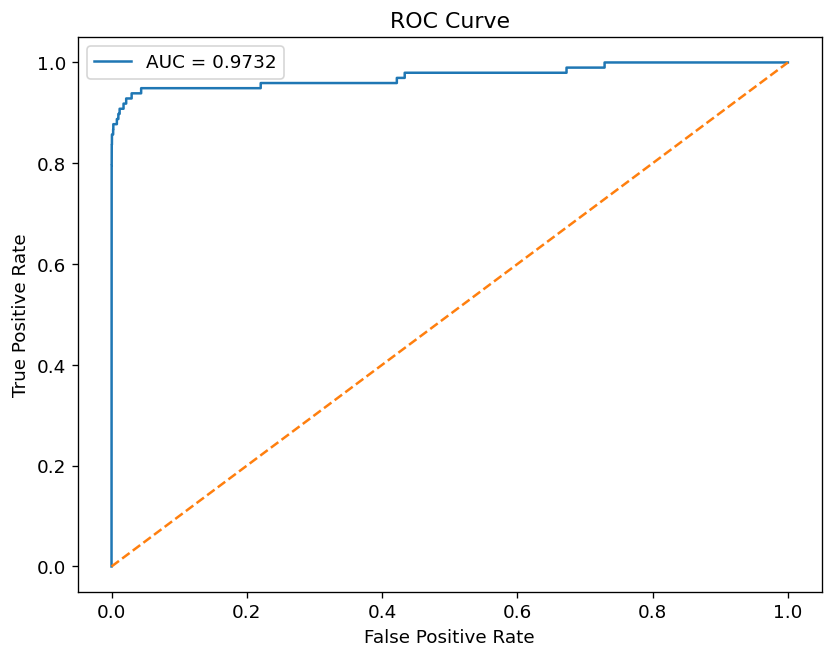

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Precision_Recall_Curve

In [19]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

In [20]:
precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

In [21]:
ap_score = average_precision_score(
    y_test,
    y_prob
)

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"AUPRC = {ap_score:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.show()